# QF 627 Programming and Computational Finance
## Problem Set `5` | `In Progress`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

In [5]:
alphas =\
(
    pd
    .read_csv("alphas.csv",
              index_col = 0,
              parse_dates = True)
)

alphas

,Alphas A,Alphas B,Alphas C
2019-05-28,100.000000,100.000000,100.000000
2019-05-29,100.562415,101.991696,100.733993
2019-05-30,98.903615,104.527038,100.568916
2019-05-31,101.046406,107.799053,99.186270
2019-06-03,101.649234,107.750748,101.323467
...,...,...,...
2023-09-06,87.171517,85.212876,88.864669
2023-09-07,87.770479,85.143390,87.782382
2023-09-08,88.204118,84.376805,87.391530
2023-09-11,88.475733,85.531184,86.241478


### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

In [6]:
def calculate_sharpe_ratio(daily_returns):
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std()

### <font color = red> Answer 1 is presented in the cell below: </font>

In [7]:
alphas.columns

Index(['Alphas A', 'Alphas B', 'Alphas C'], dtype='object')

In [42]:
answer_1 = alphas
[{key: calculate_sharpe_ratio(alphas[key].pct_change())} for key in alphas.columns]

[{'Alphas A': -0.057912193325420726},
 {'Alphas B': -0.06783329116885627},
 {'Alphas C': -0.06277900764250023}]

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

In [17]:
alphas_returns =\
(
    np
    .log(
        alphas 
        /
        alphas.shift(1)
    )
)

alphas_cumulative_returns = alphas_returns.cumsum().apply(np.exp)

### <font color = red> Answer 2 is presented in the cell below: </font>

<Axes: >

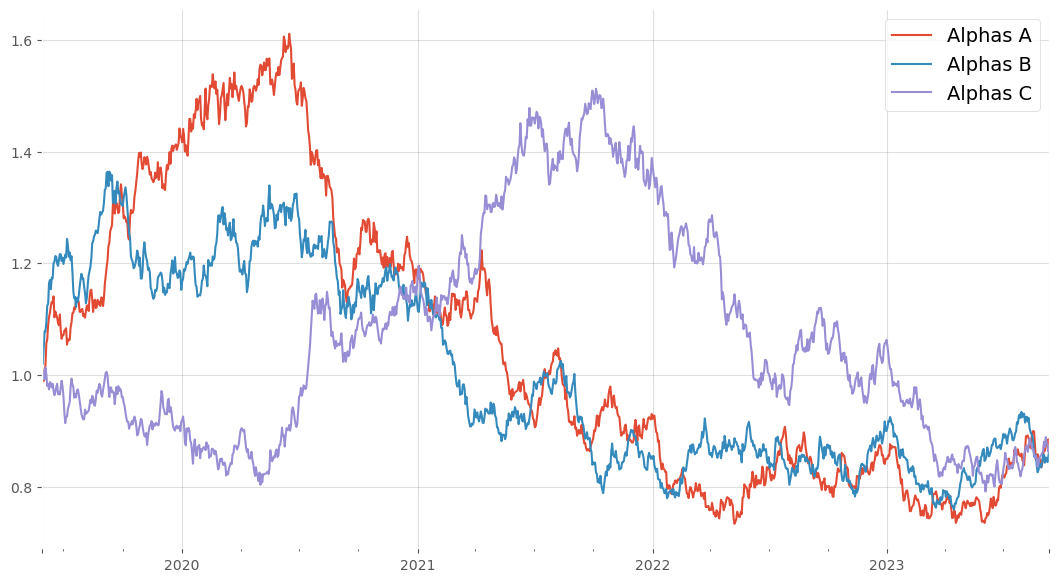

In [18]:
alphas_cumulative_returns.plot(figsize = [13, 7 ]
                              )

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

### Elegant Coding

- Scalable
- Robust
- Efficient 

In [22]:
def calculate_cagr(cumulative_returns):
    cumulative_returns = cumulative_returns.dropna()
    d = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (365.0 / d) - 1
    return cagr

### <font color = red> Answer 3 is presented in the cell below: </font>

In [20]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
alphas                      DataFrame                  Alphas A   <...>\n[1121 rows x 3 columns]
alphas_cumulative_returns   DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
alphas_returns              DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
calculate_cagr              function     <function calculate_cagr at 0x17f708ee0>
calculate_sharpe_ratio      function     <function calculate_sharpe_ratio at 0x16dbe90d0>
dt                          module       <module 'datetime' from '<...>b/python3.9/datetime.py'>
mpl                         module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                          module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
pd                          module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
pdr                         module       <modul

In [41]:
answer_3 = [
    {f"{key} CAGR": calculate_cagr(alphas_cumulative_returns[key])}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

In [26]:
def calculate_drawdown_percent(cumulative_returns):
    max_gross_performance = cumulative_returns.cummax()
    drawdown = (max_gross_performance - cumulative_returns) / max_gross_performance
    return drawdown

In [27]:
%who

alphas	 alphas_cumulative_returns	 alphas_returns	 calculate_cagr	 calculate_drawdown_percent	 calculate_sharpe_ratio	 dt	 mpl	 np	 
pd	 pdr	 plt	 yf	 
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### <font color = red> Answer 4 is presented in the cell below: </font>

In [44]:
answer_4 = [
    {f"{key} MDD": calculate_drawdown_percent(alphas_cumulative_returns[key]).max()}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

In [34]:
def calculate_longest_drawdown(cumulative_returns):
    drawdown = cumulative_returns.cummax() - cumulative_returns
    period = np.diff(np.append(drawdown[drawdown == 0].index, drawdown.index[-1: ]
                              )
                    )
    return period.max() / np.timedelta64(1, "D")

### <font color = red> Answer 5 is presented in the cell below: </font>

In [35]:
%who

alphas	 alphas_cumulative_returns	 alphas_returns	 calculate_cagr	 calculate_drawdown_percent	 calculate_longest_drawdown	 calculate_sharpe_ratio	 dt	 mpl	 
np	 pd	 pdr	 plt	 yf	 


In [45]:
answer_5 = [
    {f"{key} Longest DD": calculate_longest_drawdown(alphas_cumulative_returns[key])}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

### <font color = red> Answer 6 is presented in the cell below: </font>

In [43]:
[calculate_sharpe_ratio(alphas[key].pct_change()) for key in alphas.columns]

[-0.057912193325420726, -0.06783329116885627, -0.06277900764250023]

In [51]:
dict_to_assess =\
{
    "Sharpe": [calculate_sharpe_ratio(alphas[key].pct_change()) for key in alphas.columns],
    "CAGR": [list(unpack.values())[0] for unpack in answer_3],
    "MDD": [list(unpack.values())[0] for unpack in answer_4],
    "Longest Drawdown": [list(unpack.values())[0] for unpack in answer_5]
}

In [52]:
df_to_assess = pd.DataFrame(dict_to_assess)
df_to_assess.index = ["Alpha A", "Alpha B", "Alpha C"]

df_to_assess

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,-0.057912,-0.032403,0.544602,1183.0
Alpha B,-0.067833,-0.037295,0.443717,1463.0
Alpha C,-0.062779,-0.033521,0.476758,706.0


In [50]:
[list(unpack.values())[0] for unpack in answer_3]

[-0.03240277890861454, -0.03729517681949024, -0.03352056240207568]

In [63]:
### Ranking Method

df_for_ranking = pd.DataFrame(index = df_to_assess.index)

In [64]:
df_for_ranking

""
Alpha A
Alpha B
Alpha C


In [66]:
df_to_assess.columns

Index(['Sharpe', 'CAGR', 'MDD', 'Longest Drawdown'], dtype='object')

In [67]:
for c in df_to_assess.columns[:]:
    df_for_ranking[c] =\
    (
        df_to_assess[c]
        .rank(ascending = False)
    )

df_for_ranking

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,1.0,1.0,1.0,2.0
Alpha B,3.0,3.0,3.0,1.0
Alpha C,2.0,2.0,2.0,3.0


In [70]:
df_for_ranking.sum(axis = 1).index[0]

'Alpha A'

### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

### <font color = red> Answer 7 is presented in the cell below: </font>

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 8 is presented in the cell below: </font>

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 9 </font>

    The answer is ____________ % .

### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 11 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>